In [ ]:
# 예제 8-1 라이브러리 호출
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim



In [ ]:
# 예제 8-2 데이터셋 내려받기
trainset = torchvision.datasets.FashionMNIST(
    root='../chap08/data/',       # 저장 위치
    train=True,                   # 학습용 데이터셋
    download=True,                # 없으면 자동 다운로드
    transform=transforms.ToTensor()  # 데이터를 텐서로 변환
)

In [ ]:
# 예제 8-3 데이터셋을 메모리로 가져오기
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
# batch_size=4로 설정 → 한 번에 4개씩 데이터를 메모리로 불러옴


In [ ]:
# 예제 8-4 데이터셋 분리
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)        # 전체 배치 이미지 텐서의 shape 출력
print(images[0].shape)     # 첫 번째 이미지의 shape 확인
print(labels[0].item())    # 첫 번째 이미지의 레이블 값 출력


torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
6


In [ ]:
# 예제 8-5 이미지 데이터를 출력하기 위한 전처리
def imshow(img, title):
    plt.figure(figsize=(batch_size * 4, 4))      # 출력할 개별 이미지의 크기 지정
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0)))     # [채널, 높이, 너비] → [높이, 너비, 채널] 형태로 변환
    plt.title(title)
    plt.show()


In [ ]:
# 예제 8-6 이미지 데이터 출력 함수
def show_batch_images(dataloader):
    images, labels = next(iter(dataloader))  # 배치 크기만큼의 이미지 불러오기 (4, 1, 28, 28)

    img = torchvision.utils.make_grid(images)  # 이미지들을 하나의 그리드로 결합
    imshow(img, title=[str(x.item()) for x in labels])  # 레이블을 문자열로 출력 제목으로 설정

    return images, labels


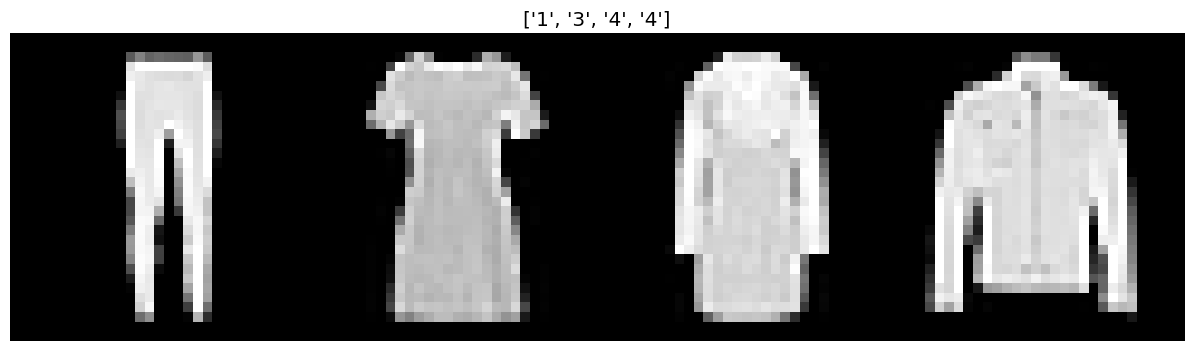

In [ ]:
# 예제 8-7 이미지 출력
images, labels = show_batch_images(trainloader)


In [ ]:
# 예제 8-8 배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48),     # (28, 28) 크기 이미지 → 784차원 입력
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Linear(24, 10)       # 출력: FashionMNIST의 10개 클래스
        )  # nn.Sequential로 계층을 순차적으로 구성

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 2D 이미지를 1D 벡터로 변환 (batch_size, 784)
        x = self.classifier(x)     # 정의된 계층(classifier) 통과
        return x


In [ ]:
# 예제 8-9 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48),         # 입력: 28x28 = 784
            nn.BatchNorm1d(48),         # 배치 정규화 → 출력 채널 수와 동일하게 설정
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.BatchNorm1d(24),         # 배치 정규화 추가
            nn.ReLU(),
            nn.Linear(24, 10)           # FashionMNIST 10개 클래스 분류
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)       # 이미지 텐서를 펼쳐서 (batch_size, 784)로 변환
        x = self.classifier(x)          # Sequential에 정의된 계층 적용
        return x


In [ ]:
# 예제 8-10 배치 정규화가 적용되지 않은 모델 선언
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 예제 8-11 배치 정규화가 적용된 모델 선언
model_bn = BNNet()
print(model_bn)


BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 예제 8-12 데이터셋 메모리로 불러오기
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)


In [ ]:
# 예제 8-13 옵티마이저, 손실 함수 지정
loss_fn = nn.CrossEntropyLoss()                            # 다중 클래스 분류 손실 함수
opt = optim.SGD(model.parameters(), lr=0.01)               # 일반 모델용 SGD 옵티마이저
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)         # 배치 정규화 모델용 SGD 옵티마이저


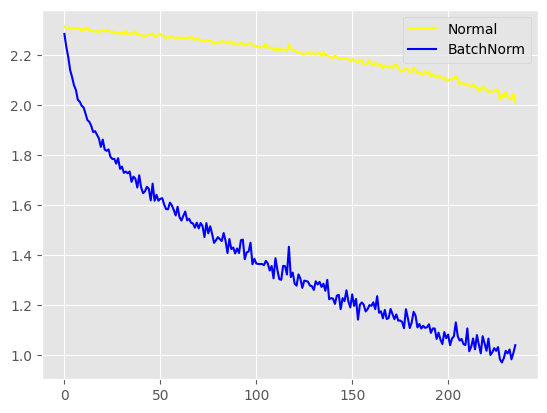

In [ ]:
# 예제 8-14 모델 학습

loss_arr = []       # 일반 모델 손실 저장 리스트
loss_bn_arr = []    # 배치 정규화 모델 손실 저장 리스트
max_epochs = 2

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):

        inputs, labels = data

        # ------- 배치 정규화가 적용되지 않은 모델 학습
        opt.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        # ------- 배치 정규화가 적용된 모델 학습
        opt_bn.zero_grad()
        outputs_bn = model_bn(inputs)
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        # ------- 손실값 저장
        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

# ------- 손실 시각화
plt.plot(loss_arr, 'yellow', label='Normal')
plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
plt.legend()
plt.show()


In [ ]:
# 예제 8-15 데이터셋의 분포를 출력하기 위한 전처리

N = 50                         # 데이터 포인트 수
noise = 0.3                    # 잡음 비율

# x_train: -1 ~ 1 사이의 값 50개를 1열로 구성한 텐서
x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)

# y_train: x_train에 정규분포 잡음을 추가
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

# 테스트 데이터셋도 동일 방식 생성
x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))


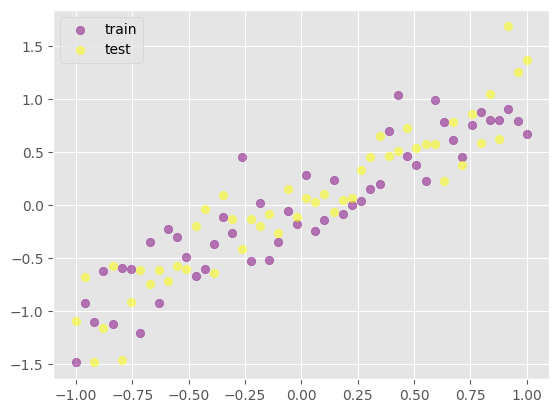

In [ ]:
# 예제 8-16 데이터 분포를 그래프로 출력

plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
            alpha=0.5, label='train')   # 학습 데이터 분포 시각화

plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
            alpha=0.5, label='test')    # 테스트 데이터 분포 시각화

plt.legend()
plt.show()


In [ ]:
# 예제 8-17 드롭아웃을 위한 모델 생성

N_h = 100  # 은닉층 뉴런 수

# 드롭아웃이 적용되지 않은 모델
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
)

# 드롭아웃이 적용된 모델
model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2),    # 드롭아웃 20% 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),    # 드롭아웃 20% 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
)


In [ ]:
# 예제 8-18 옵티마이저와 손실 함수 지정

opt = torch.optim.Adam(model.parameters(), lr=0.01)                 # 일반 모델용 옵티마이저
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)  # 드롭아웃 모델용 옵티마이저
loss_fn = torch.nn.MSELoss()                                        # 회귀 문제이므로 MSE 손실 사용


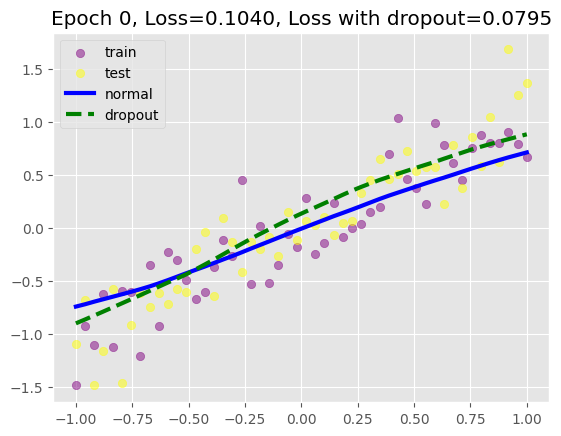

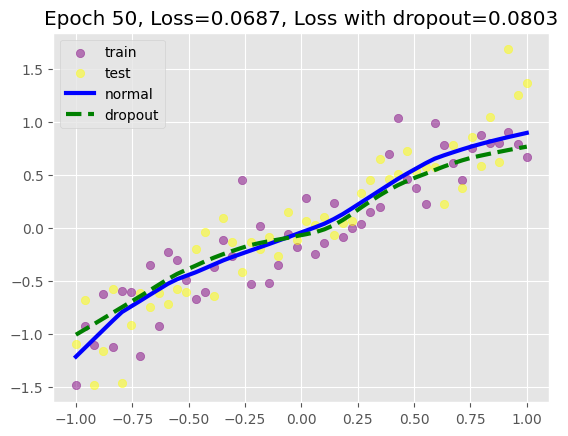

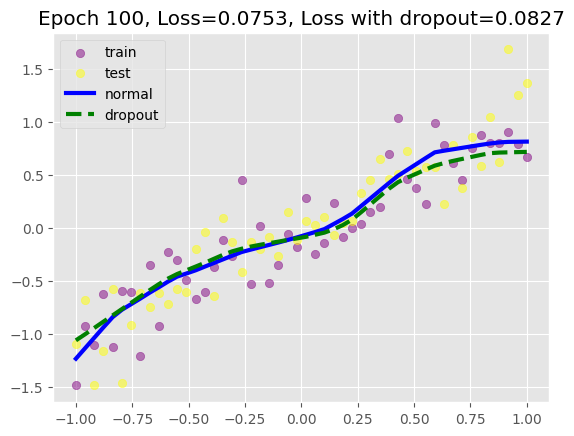

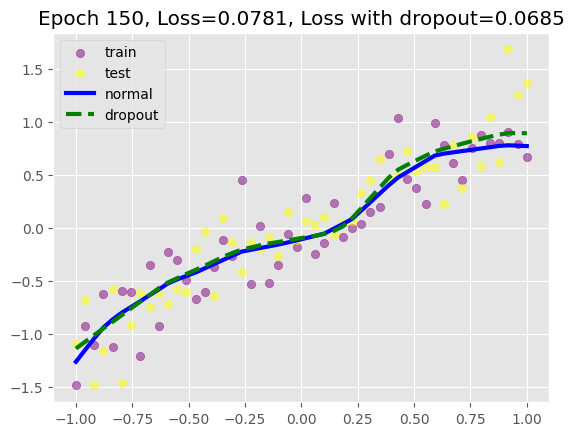

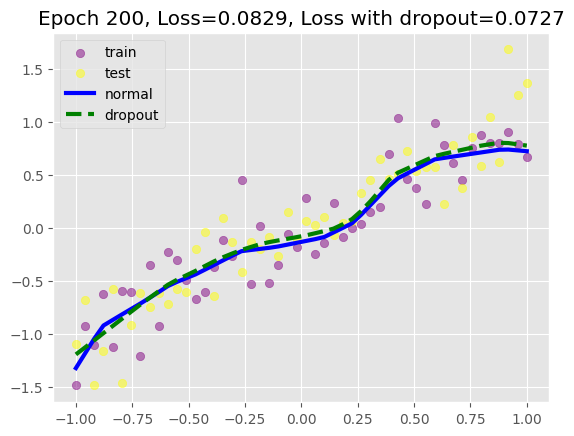

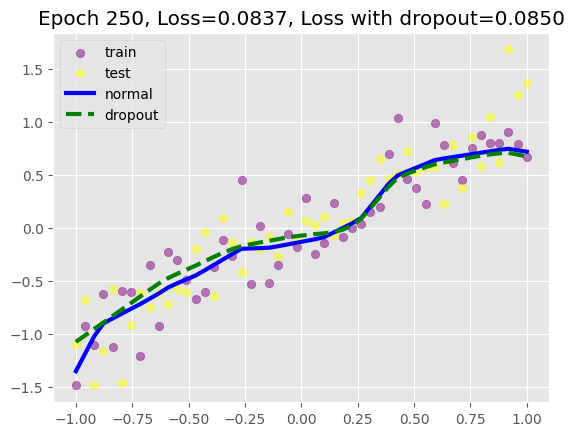

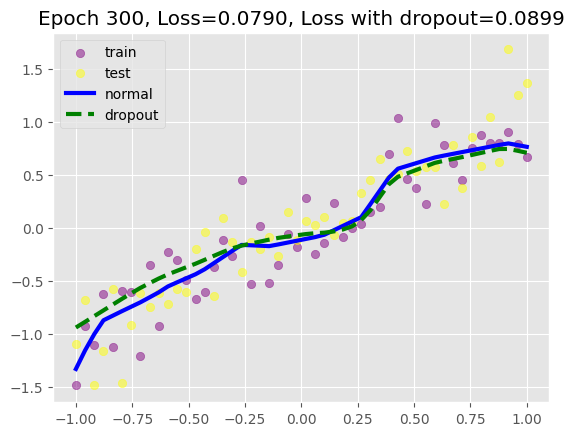

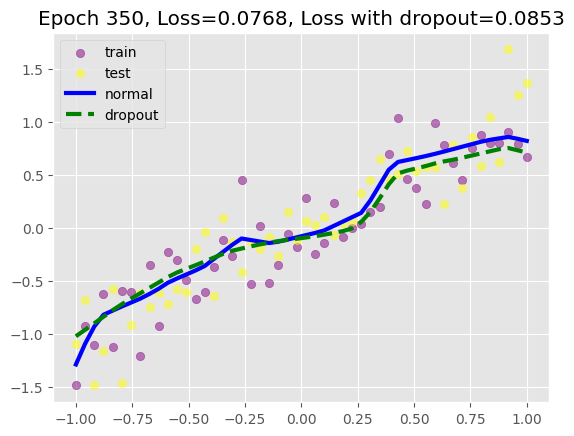

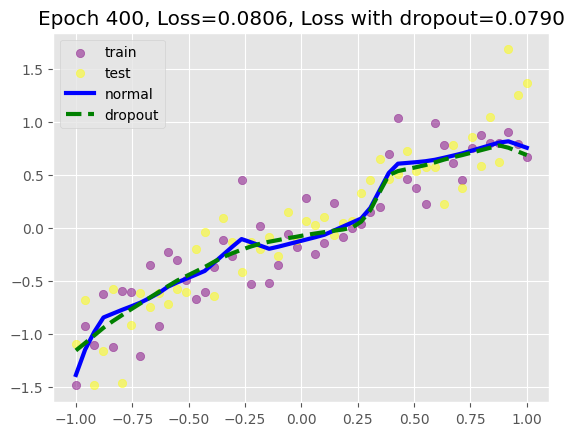

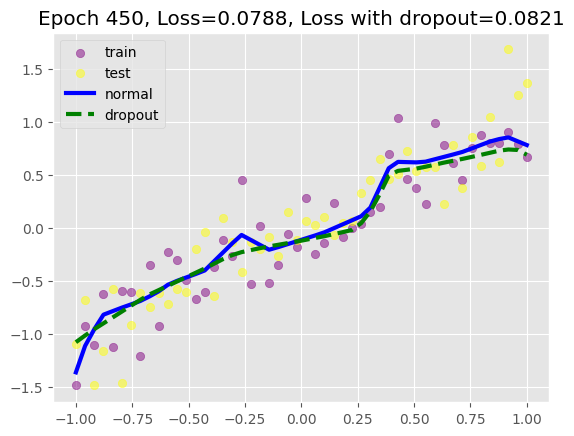

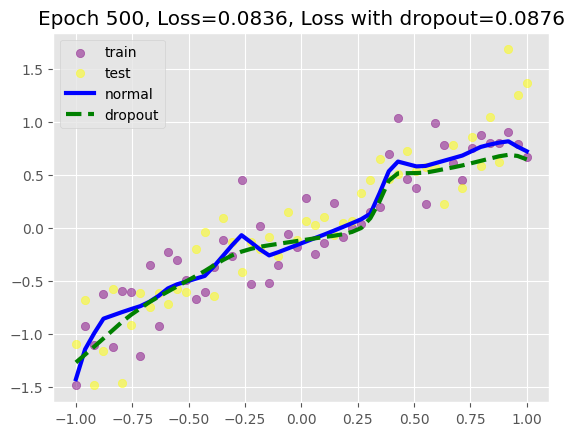

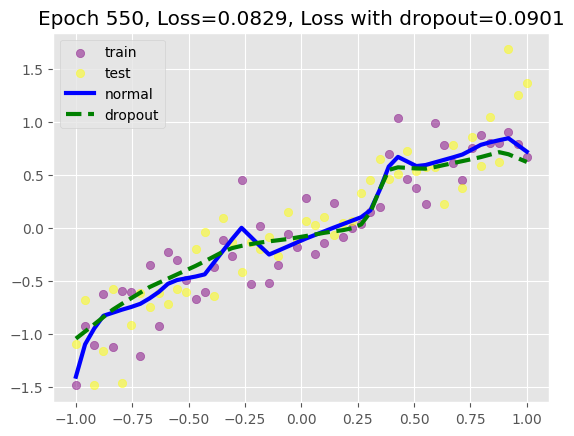

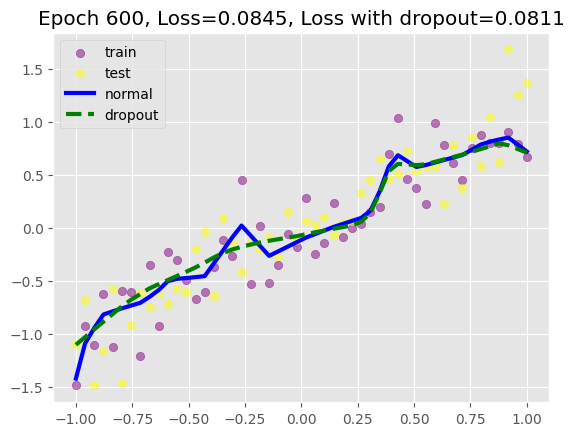

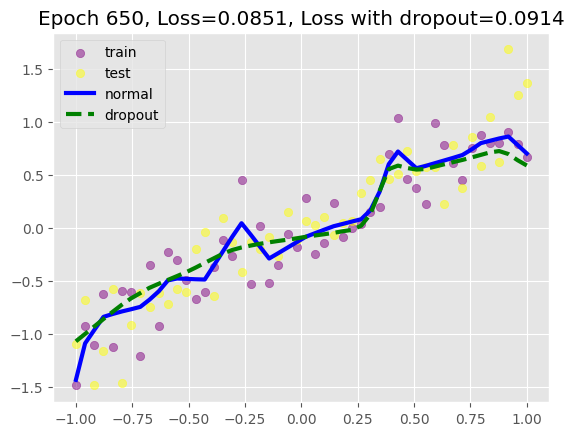

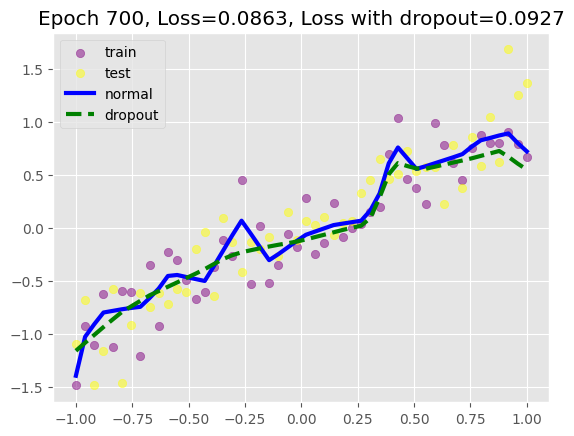

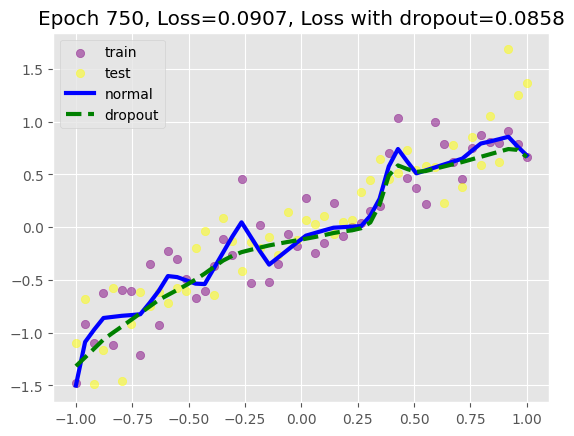

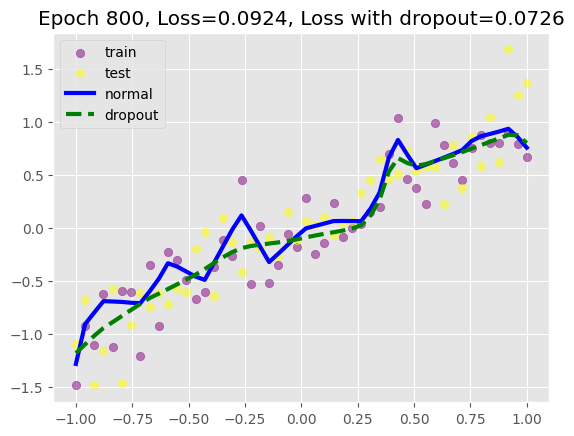

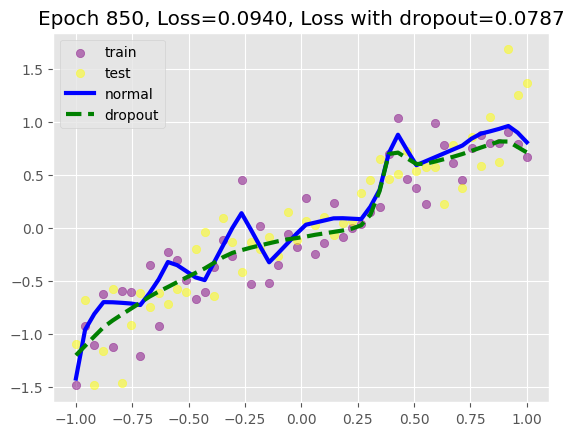

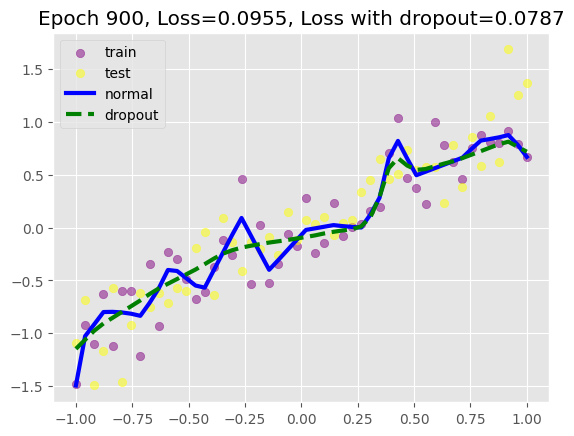

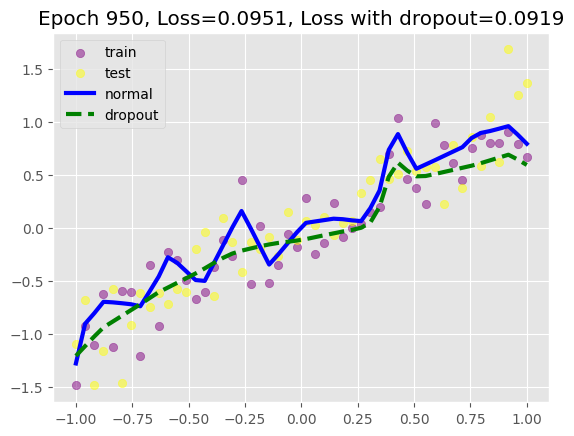

In [ ]:
# 예제 8-19 모델 학습

max_epochs = 1000

for epoch in range(max_epochs):

    # ------- 드롭아웃 미적용 모델 학습
    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    opt.zero_grad()
    loss.backward()
    opt.step()

    # ------- 드롭아웃 적용 모델 학습
    pred_dropout = model_dropout(x_train)
    loss_dropout = loss_fn(pred_dropout, y_train)
    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    # ------- 매 50 epoch마다 테스트 및 시각화
    if epoch % 50 == 0:
        model.eval()
        model_dropout.eval()

        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

        test_pred_dropout = model_dropout(x_test)
        test_loss_dropout = loss_fn(test_pred_dropout, y_test)

        # 데이터 시각화
        plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple', alpha=0.5, label='train')
        plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow', alpha=0.5, label='test')

        # 드롭아웃 미적용 모델 예측 결과
        plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3, label='normal')

        # 드롭아웃 적용 모델 예측 결과
        plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3, label='dropout')

        plt.title('Epoch %d, Loss=%.4f, Loss with dropout=%.4f' %
                  (epoch, test_loss, test_loss_dropout))
        plt.legend()
        model.train()
        model_dropout.train()
        plt.pause(0.05)


#조기 종료

In [ ]:
# 예제 8-20 라이브러리 호출

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models        # 사전 학습된 모델 사용 시 활용
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time

import argparse
from tqdm import tqdm

# 그래프 출력 스타일 지정
matplotlib.style.use('ggplot')  # 눈에 잘 띄는 스타일

# GPU 사용 가능 시 'cuda:0', 그렇지 않으면 'cpu'로 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:
# 예제 8-21 데이터셋 전처리

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                    # 이미지 크기 조정
    transforms.RandomHorizontalFlip(),                # 수평 뒤집기 (데이터 증강)
    transforms.RandomVerticalFlip(),                  # 수직 뒤집기 (데이터 증강)
    transforms.ToTensor(),                            # 텐서로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # 평균 정규화 (ImageNet 기준)
                         std=[0.229, 0.224, 0.225])   # 표준편차 정규화
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),                    # 검증용은 고정된 크기만 적용
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
from google.colab import files
uploaded = files.upload()  # archive.zip 선택


Saving archive.zip to archive (1).zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("data")  # data/archive/train, data/archive/test 형태로 풀림



In [ ]:
import os

# 최상위 폴더 구조 출력
for root, dirs, files in os.walk("data"):
    print("📁", root)
    for d in dirs:
        print(" ┗━ 📂", d)
    for f in files:
        print(" ┗━ 📄", f)
    break  # 최상위만 출력


📁 data
 ┗━ 📂 train
 ┗━ 📂 test


In [ ]:
# 예제 8-22 데이터셋 가져오기

train_dataset = datasets.ImageFolder(
    root='data/train',         # 압축 해제 후 기준 경로
    transform=train_transform
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True
)

val_dataset = datasets.ImageFolder(
    root='data/test',          # 압축 해제 후 기준 경로
    transform=val_transform
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False
)


In [ ]:
# 예제 8-23 모델 생성 (사전 학습된 ResNet50 불러오기)

def resnet50(pretrained=True, requires_grad=False):
    model = models.resnet50(progress=True, pretrained=pretrained)  # 사전 학습된 ResNet50 불러오기

    if requires_grad == False:
        # 모든 파라미터의 requires_grad=False 설정 → 학습 중 기울기 계산 안 함 (고정)
        for param in model.parameters():
            param.requires_grad = False

    elif requires_grad == True:
        # 모든 파라미터의 requires_grad=True 설정 → 학습 가능
        for param in model.parameters():
            param.requires_grad = True

    # 최종 fc 계층 수정 (출력 클래스 수 = 2로 설정)
    model.fc = nn.Linear(2048, 2)

    return model


In [ ]:
# 예제 8-24 학습률 감소 (Learning Rate Scheduler)

class LRScheduler():
    def __init__(self, optimizer, patience=5, min_lr=1e-6, factor=0.5):
        self.optimizer = optimizer
        self.patience = patience
        self.min_lr = min_lr
        self.factor = factor
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,        # 옵티마이저 객체
            mode='min',            # val_loss 기준으로 최소값 추적
            patience=self.patience,
            factor=self.factor,
            min_lr=self.min_lr,
            verbose=True           # 줄어들 때마다 로그 출력
        )

    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss)  # 검증 손실 기준으로 step 진행


In [ ]:
# 예제 8-25 조기 종료 (EarlyStopping 클래스)

class EarlyStopping():
    def __init__(self, patience=5, verbose=False, delta=0, path='./chap08/data/checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)

        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} → {val_loss:.6f}). Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


In [ ]:

# argparse 대체 수동 설정
args = {
    'lr_scheduler': True,
    'early_stopping': True,
}


In [ ]:
# 예제 8-27 사전 훈련된 모델의 파라미터 확인

import torch
import torchvision.models as models

# GPU가 가능하면 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# 사전 학습된 ResNet50 모델 불러오기
model = models.resnet50(pretrained=True).to(device)

# 전체 파라미터 수
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")

# 학습 가능한 파라미터 수
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")


Computation device: cuda



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


25,557,032 total parameters.
25,557,032 training parameters.


In [ ]:
# 예제 8-28 옵티마이저와 손실 함수 지정
import torch.nn as nn
import torch.optim as optim

lr = 0.001
epochs = 100

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()


In [ ]:
# 예제 8-29 오차, 정확도 및 모델 이름에 대한 문자열
loss_plot_name = 'loss'        # 오차 그래프 저장 시 사용할 이름
acc_plot_name = 'accuracy'     # 정확도 그래프 저장 시 사용할 이름
model_name = 'model'           # 저장할 모델 파일 이름


In [ ]:
#8-30

# 조건부 학습률 감소 초기화
if args['lr_scheduler']:
    print('INFO: Initializing learning rate scheduler')
    lr_scheduler = LRScheduler(optimizer)

    # 학습률 감소 시 사용하는 이름 설정
    loss_plot_name = 'lrs_loss'
    acc_plot_name = 'lrs_accuracy'
    model_name = 'lrs_model'

# 조건부 조기 종료 초기화
if args['early_stopping']:
    print('INFO: Initializing early stopping')
    early_stopping = EarlyStopping()

    # 조기 종료 시 사용하는 이름 설정 (우선순위로 덮어씀)
    loss_plot_name = 'es_loss'
    acc_plot_name = 'es_accuracy'
    model_name = 'es_model'


INFO: Initializing learning rate scheduler
INFO: Initializing early stopping


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
# 예제 8-31 모델 학습 함수
def training(model, train_dataloader, train_dataset, optimizer, criterion):
    print('Training')
    model.train()
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    total = 0

    prog_bar = tqdm(enumerate(train_dataloader), total=int(len(train_dataset) / train_dataloader.batch_size))  # 훈련 진행 시각화

    for i, data in prog_bar:
        counter += 1
        data, target = data[0].to(device), data[1].to(device)
        total += target.size(0)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        train_running_loss += loss.item()

        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == target).sum().item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / counter
    train_accuracy = 100. * train_running_correct / total
    return train_loss, train_accuracy


In [ ]:
# 예제 8-32 모델 검증 함수

def validate(model, test_dataloader, val_dataset, criterion):
    print('Validating')
    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    counter = 0
    total = 0

    prog_bar = tqdm(
        enumerate(test_dataloader),
        total=int(len(val_dataset) / test_dataloader.batch_size)  # 모델 검증 과정을 시각적으로 표현
    )

    with torch.no_grad():  # 평가 시 gradient 계산 생략
        for i, data in prog_bar:
            counter += 1
            data, target = data[0].to(device), data[1].to(device)
            total += target.size(0)

            outputs = model(data)
            loss = criterion(outputs, target)

            val_running_loss += loss.item()
            _, preds = torch.max(outputs.data, 1)
            val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total

    return val_loss, val_accuracy


In [ ]:
import os

os.makedirs('./chap08/data', exist_ok=True)


In [ ]:
# 예제 8-33 모델 학습

train_loss, train_accuracy = [], []  # 훈련 데이터셋 기준 오차 및 정확도 저장용 리스트
val_loss, val_accuracy = [], []      # 검증 데이터셋 기준 오차 및 정확도 저장용 리스트

start = time.time()

for epoch in range(epochs):
    print(f"Epoch {epoch+1} of {epochs}")

    train_epoch_loss, train_epoch_accuracy = training(
        model, train_dataloader, train_dataset, optimizer, criterion
    )

    val_epoch_loss, val_epoch_accuracy = validate(
        model, val_dataloader, val_dataset, criterion
    )

    train_loss.append(train_epoch_loss)
    train_accuracy.append(train_epoch_accuracy)
    val_loss.append(val_epoch_loss)
    val_accuracy.append(val_epoch_accuracy)

    if args['lr_scheduler']:  # 학습률 스케줄러 사용 시
        lr_scheduler(val_epoch_loss)

    if args['early_stopping']:  # 조기 종료 사용 시
        early_stopping(val_epoch_loss, model)
        if early_stopping.early_stop:
            break

    print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
    print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")

end = time.time()
print(f"Training time: {(end-start)/60:.3f} minutes")


Epoch 1 of 100
Training


16it [00:04,  3.51it/s]


Validating


16it [00:03,  4.86it/s]


Train Loss: 0.5030, Train Acc: 77.31
Val Loss: 0.8337, Val Acc: 70.60
Epoch 2 of 100
Training


...

EarlyStopping counter: 4 out of 5
Train Loss: 0.2436, Train Acc: 89.36
Val Loss: 0.9430, Val Acc: 66.60
Epoch 12 of 100
Training


16it [00:04,  3.39it/s]


Validating


16it [00:03,  4.61it/s]

EarlyStopping counter: 5 out of 5
Training time: 1.637 minutes


Saving loss and accuracy plots...


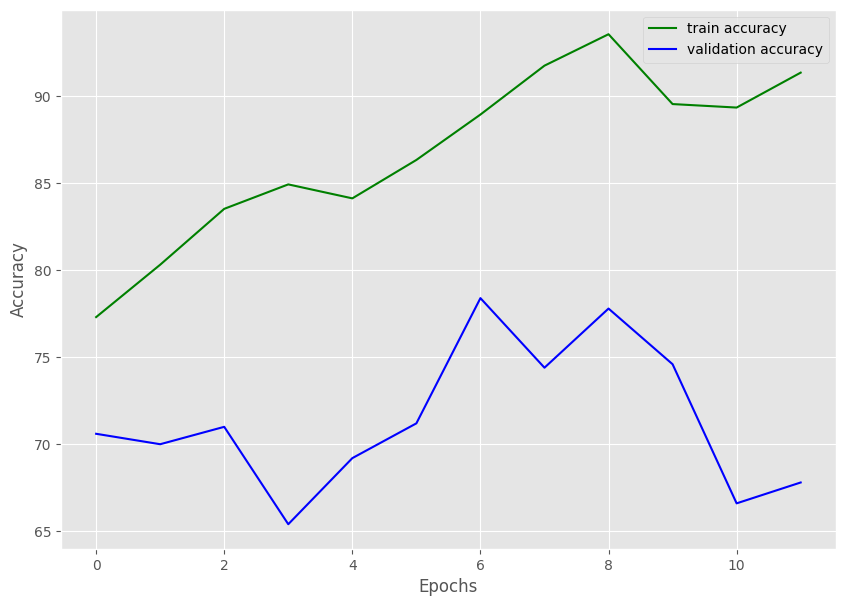

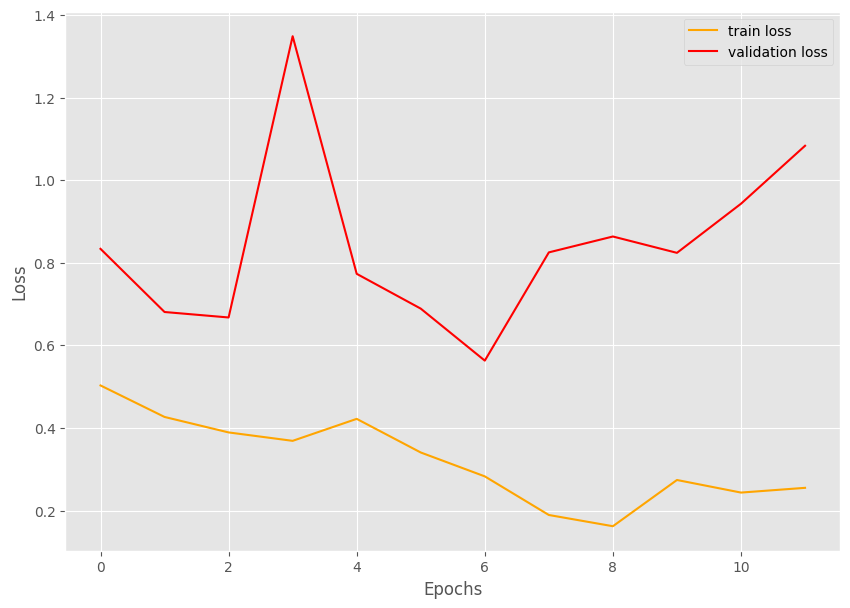

Saving model...
TRAINING COMPLETE


In [ ]:
# 예제 8-34 모델 학습 결과 출력

print('Saving loss and accuracy plots...')

# 정확도 그래프
plt.figure(figsize=(10, 7))
plt.plot(train_accuracy, color='green', label='train accuracy')     # 훈련 정확도
plt.plot(val_accuracy, color='blue', label='validation accuracy')   # 검증 정확도
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"../chap08/img/{acc_plot_name}.png")
plt.show()

# 손실 그래프
plt.figure(figsize=(10, 7))
plt.plot(train_loss, color='orange', label='train loss')            # 훈련 손실
plt.plot(val_loss, color='red', label='validation loss')            # 검증 손실
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"../chap08/img/{loss_plot_name}.png")
plt.show()

# 모델 저장
print('Saving model...')
torch.save(model.state_dict(), f"../chap08/img/{model_name}.pth")
print('TRAINING COMPLETE')
